## 01 Data loading, exploration and anaylsis

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

### 01.1 Data loading and enrichment

In [29]:
def extend_data(df):
    month_dict = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

    #add column for the month number
    df['month_num'] = df['month'].map(month_dict)

    #insert column with the year
    #new year if month_num is smaller than the previous row's month_num
    new_year_mask = df['month_num'] < df['month_num'].shift(1)

    #cummulative sum
    year_offset = new_year_mask.cumsum()
    
    #calculate year starting at 2008
    df['year'] = 2008 + year_offset

    return df

In [30]:
path = 'C:/Users/Dimitra/Desktop/jupyterlab/notebook/datasets/'

In [31]:
#load bank-full dataset
file_path = path+'bank-full.csv'
df_full = pd.read_csv(file_path, sep=';')

In [32]:
#compare data to documentation, whether undocumented values occur
#{col: full_df[col].unique() for col in full_df.columns if full_df[col].dtype != 'int64'}

In [33]:
#load bank-addition-full dataset
file_path = path+'bank-additional-full.csv'
df_add = pd.read_csv(file_path, sep=';')

In [34]:
#compare data to documentation, whether undocumented values occur
#{col: add_df[col].unique() for col in add_df.columns if add_df[col].dtype != 'int64'}

In [35]:
df_full = extend_data(df_full)
df_add = extend_data(df_add)

In [36]:
#calculate the average of the new columns from bank-addiational-full for each month 
target_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

df_add_avg = df_add.groupby(['year', 'month_num'])[target_cols].mean().reset_index()

In [37]:
#add data for jan and feb of 2009 and 2010

missing_rows = [
    {'month_num': 1, 'year': 2009},
    {'month_num': 2, 'year': 2009},
    {'month_num': 1, 'year': 2010},
    {'month_num': 2, 'year': 2010}
]
#add rows for missing month
df_add_avg = pd.concat([df_add_avg, pd.DataFrame(missing_rows)], ignore_index=True)
#sort datafrome (for correct interpolation)
df_add_avg = df_add_avg.sort_values(['year', 'month_num']).reset_index(drop=True)

#interpolate missing values
cols_inter = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
df_missing = df_add_avg[cols_inter]

df_interpolated = df_missing.interpolate(method='linear', axis=0)
df_add_avg[cols_inter] = df_interpolated

#add values for euribor3m from online source
#https://www.euribor-rates.eu/en/euribor-rates-by-year/2008/#:~:text=Table_title:%20Euribor%20interest%20rates%202008%20Table_content:%20header:,%7C%20Euribor%206%20months:%205.165%20%25%20%7C
df_add_avg.loc[(df_add_avg['month_num'] == 1) & (df_add_avg['year'] == 2009), 'euribor3m'] = 2.859
df_add_avg.loc[(df_add_avg['month_num'] == 2) & (df_add_avg['year'] == 2009), 'euribor3m'] = 2.077
df_add_avg.loc[(df_add_avg['month_num'] == 1) & (df_add_avg['year'] == 2010), 'euribor3m'] = 0.7
df_add_avg.loc[(df_add_avg['month_num'] == 2) & (df_add_avg['year'] == 2010), 'euribor3m'] = 0.665


In [38]:
#merge the averages from the additional columns from bank-additional-full and online data into bank-full dataset
key_cols = ['month_num', 'year']
new_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

df_merged = pd.merge(df_full, df_add_avg[key_cols + new_cols], 
                     on=key_cols, 
                     how='left', 
                     suffixes=('_full', '_add'))

In [39]:
#exclude 'duration' and 'campaign' from further analysis as they should not be used for the model / the prediction
#remove 'month' as it is redundant with 'month_num' / rename afterwards 'month_num' to 'month'
df_merged.drop(columns=['duration', 'campaign', 'month'], inplace=True)
df_merged.rename(columns={'month_num': 'month'}, inplace=True)

In [40]:
#check for null values and count 'unknown' values
summary = pd.DataFrame({
    'null_values': df_merged.isnull().sum(),
    'unknown_values': (df_merged == 'unknown').sum()
})

print(summary) 

                null_values  unknown_values
age                       0               0
job                       0             288
marital                   0               0
education                 0            1857
default                   0               0
balance                   0               0
housing                   0               0
loan                      0               0
contact                   0           13020
day                       0               0
pdays                     0               0
previous                  0               0
poutcome                  0           36959
y                         0               0
month                     0               0
year                      0               0
emp.var.rate              0               0
cons.price.idx            0               0
cons.conf.idx             0               0
euribor3m                 0               0
nr.employed               0               0


non null values, unknown values only in 4 columns --> okay to continue

### 01.2 Outlier analysis and univariat analysis

In [42]:
#outlier and univariate analysis function for a nummerical column
def analyze_nummerical(df, column):
    print(f"---------------------- Analysis for: {column} ----------------------")
    
    #IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    iqr_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    #Z-Score (Identifying values more than 3 standard deviations from the mean)
    z_scores = np.abs(stats.zscore(df[column], nan_policy='omit'))
    z_outliers_count = (z_scores > 3).sum() 
    
    #print basic statistics
    print(f"Min value: {df[column].min()} | Max value: {df[column].max()}")
    print(f"IQR Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
    print(f"IQR Outliers: {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.2f}%)")
    print(f"Z-Score Outliers (>3SD): {z_outliers_count} ({z_outliers_count/len(df)*100:.2f}%)")
    
    #visualization with plots
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
    #boxplot for quartiles and outliers
    sns.boxplot(x=df[column], ax=axes[0], palette="viridis")
    axes[0].set_title(f'Boxplot of {column}')
    
    #histogram with Kernel Density Estimation (KDE) to show distribution
    sns.histplot(df[column], kde=True, ax=axes[1], color="teal")
    axes[1].set_title(f'Distribution of {column}')
    
    plt.tight_layout()
    plt.show()

In [43]:
#univariate analysis function for a categorical column
def analyze_categorical(df, column):
    print(f"---------------------- Analysis for: {column} ----------------------")
    
    counts = df[column].value_counts(dropna=False)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    #print chart
    ax_bar = sns.countplot(
        data=df, 
        y=column, 
        ax=ax, 
        palette="viridis", 
        order=counts.index
    )
    ax.set_title(f'Top Categories of {column}')
    
    #adding the percentage labels to the bars
    total = len(df[column])
    for container in ax_bar.containers:
        # Create labels with absolute count and percentage
        labels = [f' {x:,.0f} ({x/total:.1%})' for x in container.datavalues]
        ax_bar.bar_label(container, labels=labels, padding=3, fontsize=9)
    
    ax.set_xlim(0, counts.max() * 1.3)
    
    plt.tight_layout()
    plt.show()


---------------------- Analysis for: age ----------------------
Min value: 18 | Max value: 95
IQR Lower Bound: 10.50 | Upper Bound: 70.50
IQR Outliers: 487 (1.08%)
Z-Score Outliers (>3SD): 381 (0.84%)


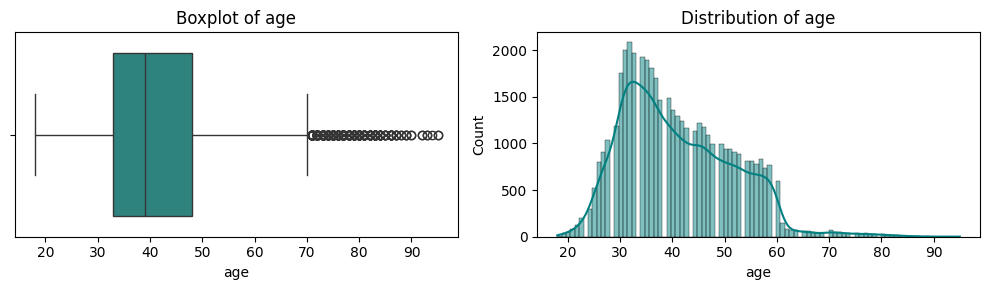

---------------------- Analysis for: balance ----------------------
Min value: -8019 | Max value: 102127
IQR Lower Bound: -1962.00 | Upper Bound: 3462.00
IQR Outliers: 4729 (10.46%)
Z-Score Outliers (>3SD): 745 (1.65%)


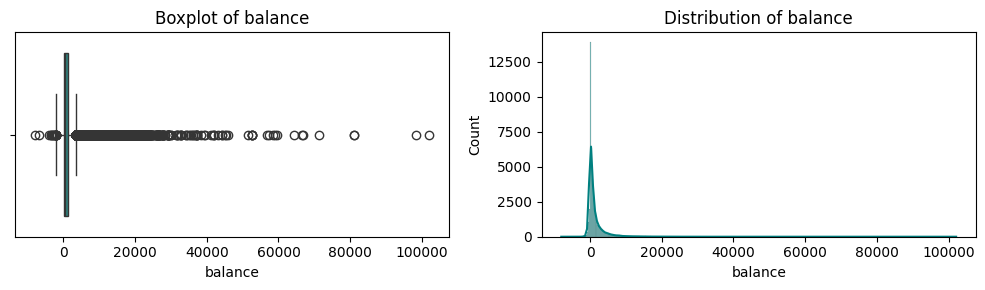

---------------------- Analysis for: pdays ----------------------
Min value: -1 | Max value: 871
IQR Lower Bound: -1.00 | Upper Bound: -1.00
IQR Outliers: 8257 (18.26%)
Z-Score Outliers (>3SD): 1723 (3.81%)


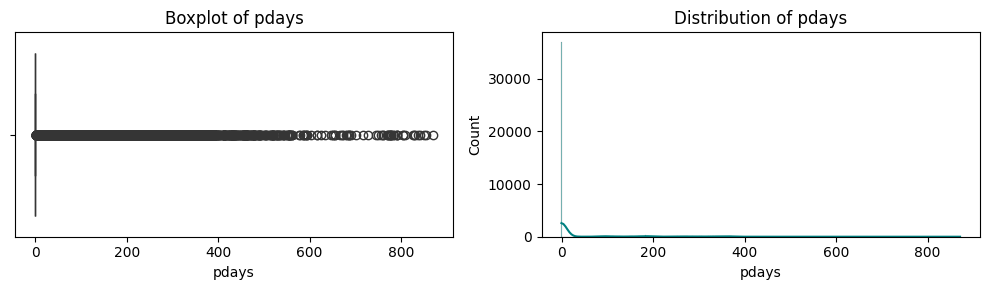

---------------------- Analysis for: previous ----------------------
Min value: 0 | Max value: 275
IQR Lower Bound: 0.00 | Upper Bound: 0.00
IQR Outliers: 8257 (18.26%)
Z-Score Outliers (>3SD): 582 (1.29%)


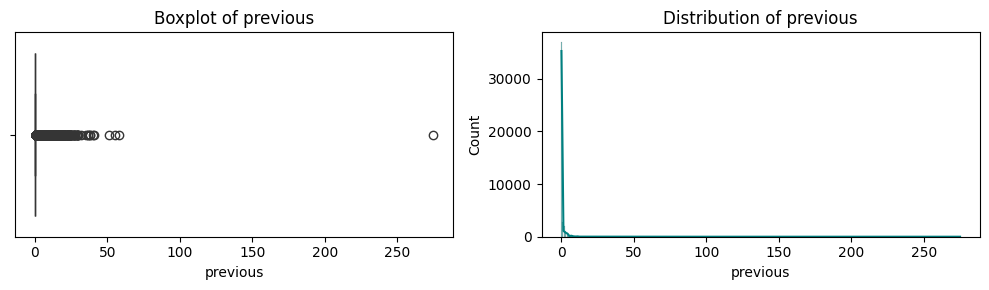

---------------------- Analysis for: emp.var.rate ----------------------
Min value: -3.4 | Max value: 1.4
IQR Lower Bound: -6.60 | Upper Bound: 6.20
IQR Outliers: 0 (0.00%)
Z-Score Outliers (>3SD): 0 (0.00%)


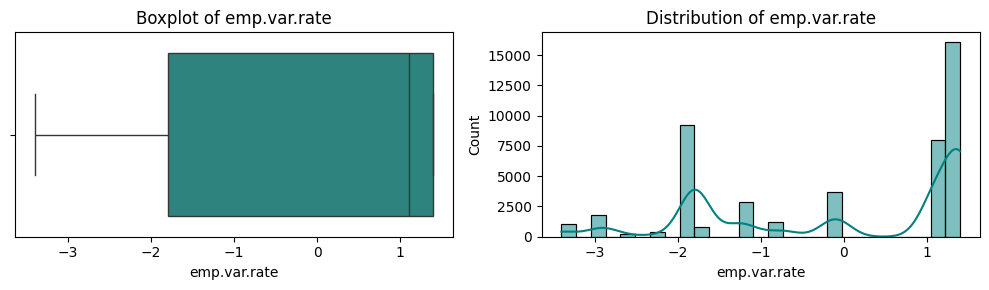

---------------------- Analysis for: cons.price.idx ----------------------
Min value: 92.201 | Max value: 94.767
IQR Lower Bound: 91.24 | Upper Bound: 95.65
IQR Outliers: 0 (0.00%)
Z-Score Outliers (>3SD): 0 (0.00%)


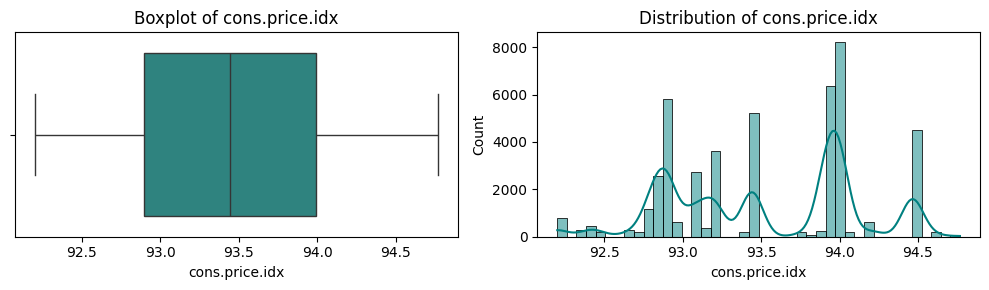

---------------------- Analysis for: cons.conf.idx ----------------------
Min value: -50.8 | Max value: -26.9
IQR Lower Bound: -60.90 | Upper Bound: -21.70
IQR Outliers: 0 (0.00%)
Z-Score Outliers (>3SD): 0 (0.00%)


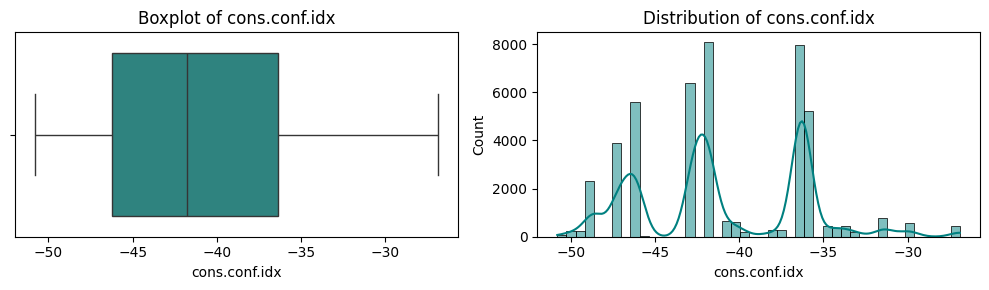

---------------------- Analysis for: euribor3m ----------------------
Min value: 0.6455459770114943 | Max value: 4.964804251207729
IQR Lower Bound: -3.91 | Upper Bound: 10.29
IQR Outliers: 0 (0.00%)
Z-Score Outliers (>3SD): 0 (0.00%)


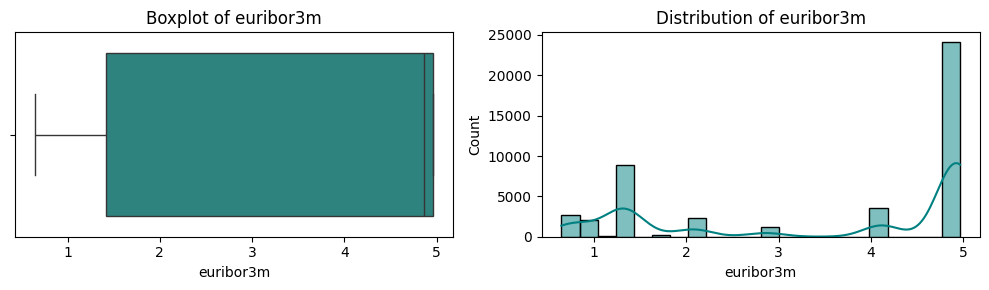

---------------------- Analysis for: nr.employed ----------------------
Min value: 4963.6 | Max value: 5228.1
IQR Lower Bound: 4905.60 | Upper Bound: 5421.60
IQR Outliers: 0 (0.00%)
Z-Score Outliers (>3SD): 0 (0.00%)


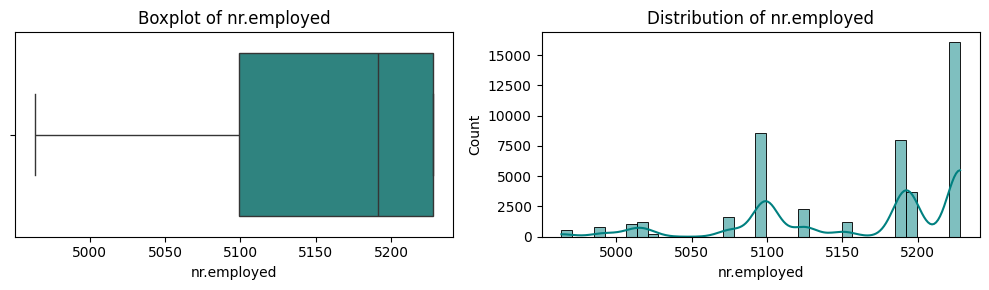

In [44]:
#list of numerical columns in the dataframe
numerical_cols = df_merged.select_dtypes(include=['int64', 'float64']).columns

#columns to exclude from analysis
numerical_cols = numerical_cols.drop(['day', 'month', 'year'], errors='ignore')

#run analysis for nummerical columns
for col in numerical_cols:
    if col in df_merged.columns:
        analyze_nummerical(df_merged, col)

outliers for column 'age' are explainable (persons up to 95 could be part of the dataset), i.e. should  be kept <br>
outliers for column 'balance' are explainable (low and high balances are possible), i.e. should  be kept <br>
outliers for column 'pdays' are '-1' values which represent missing values --> reduce to simple value representing the information whether a previous contact has happend or not <br>
outliers for column 'previous' has significant perentage of outliers --> reduce to simple value (together with 'pdays') <br>
outliers for columns 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m' and 'nr.employed' have no outliers, hence nothing to change <br>

In [46]:
#reduce information from 'previous' and 'pdays' into the column 'poutcome'

#set 'no_contact' in 'poutcome' where 'pdays' is -1
df_merged.loc[df_merged['pdays'] == -1, 'poutcome'] = 'no_contact' 

#change 'unknown' values to 'other' in 'poutcome'
df_merged.loc[df_merged['poutcome'] == 'unknown', 'poutcome'] = 'other'

#drop the columns 'pdays' and 'previous'
df_merged.drop(columns=['pdays', 'previous'], inplace=True)

#reorder the columns
df_merged = df_merged[['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'poutcome', 'day', 'month', 'year', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']]


---------------------- Analysis for: job ----------------------


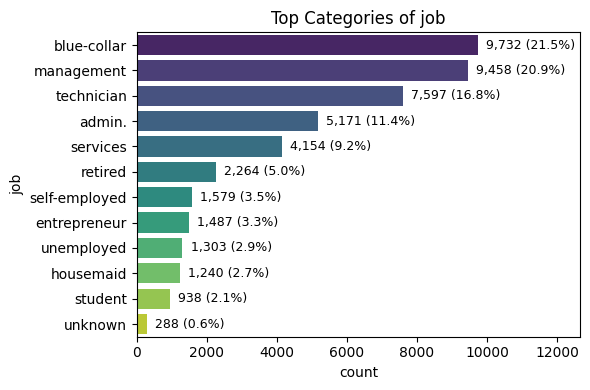

---------------------- Analysis for: marital ----------------------


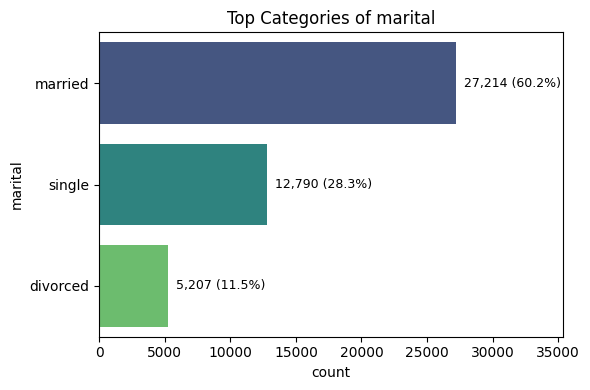

---------------------- Analysis for: education ----------------------


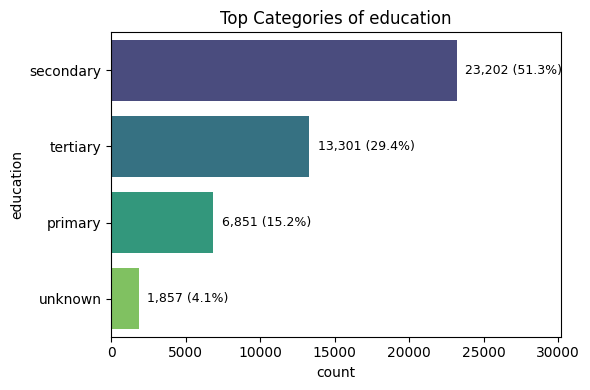

---------------------- Analysis for: default ----------------------


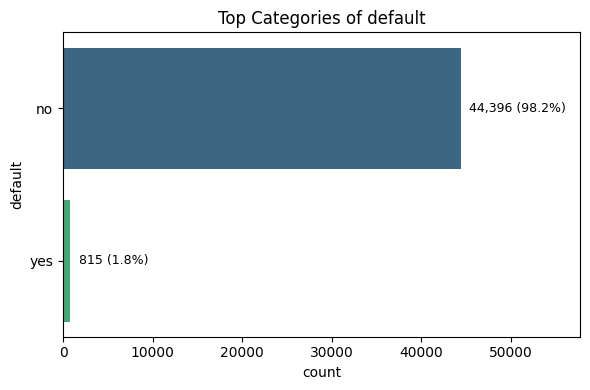

---------------------- Analysis for: housing ----------------------


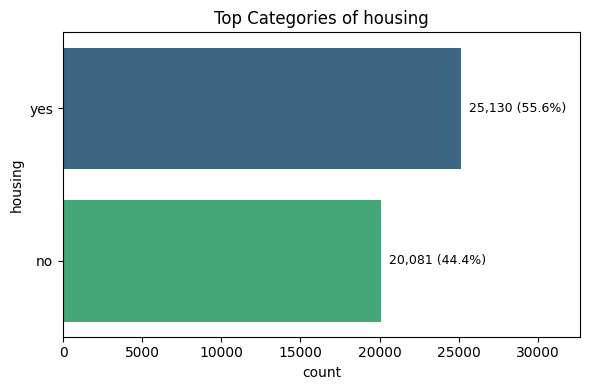

---------------------- Analysis for: loan ----------------------


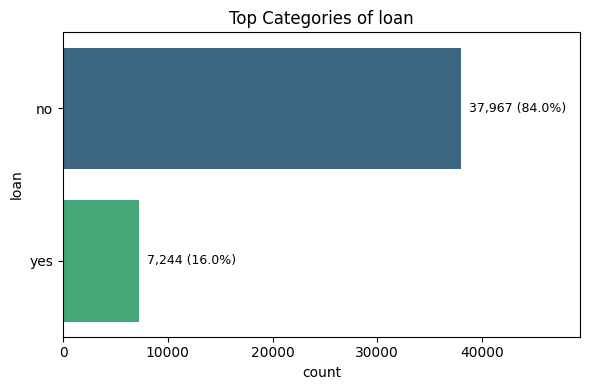

---------------------- Analysis for: contact ----------------------


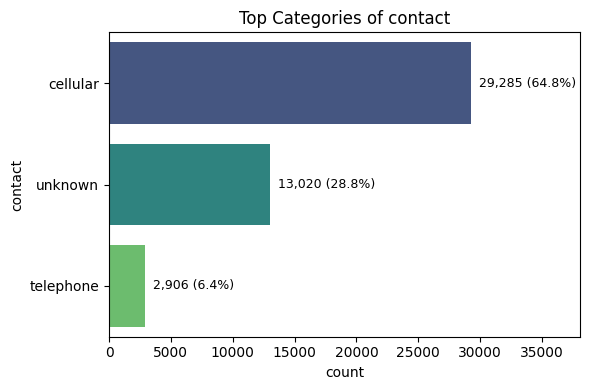

---------------------- Analysis for: poutcome ----------------------


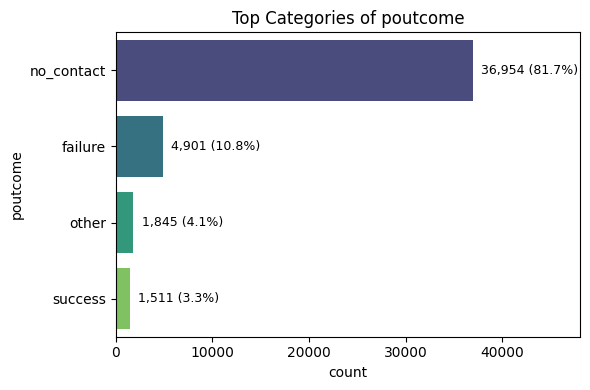

---------------------- Analysis for: y ----------------------


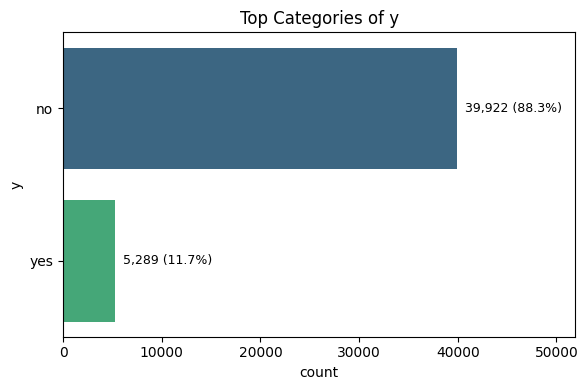

In [47]:
#list of categorical columns in the dataframe (strings or categories)
categorical_cols = df_merged.select_dtypes(include=['object', 'category']).columns

#columns to exclude from analysis (e.g., if you want to skip the target variable 'y')
categorical_cols = categorical_cols.drop(['some_id_column'], errors='ignore')

#run analysis for categorical columns
for col in categorical_cols:
    if col in df_merged.columns:
        analyze_categorical(df_merged, col)


the univariate analysis for both nummerical and categorical columns does not dictate further actions

### 01.3 Bivariate analysis

In [49]:
#bivaraiate analysis for a column compared to 'y'
def analyze_bivariate(df, column, target='y', bins=None):
    print(f"------------------ Bivariate Analysis: {column} vs {target} ------------------")
    
    temp_df = df.copy()
    current_col = column

    #make bins
    if bins is not None and pd.api.types.is_numeric_dtype(df[column]):
        temp_df[f'{column}_bins'] = pd.cut(df[column], bins=bins)
        current_col = f'{column}_bins'
        is_categorical = True
    else:
        is_categorical = not pd.api.types.is_numeric_dtype(df[column]) or df[column].nunique() <= 15

    #plot for categorical columns
    if not is_categorical:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sns.boxplot(data=temp_df, x=target, y=current_col, ax=axes[0], palette="viridis")
        axes[0].set_title(f'Boxplot: {current_col} by {target}')
        
        sns.kdeplot(data=temp_df, x=current_col, hue=target, fill=True, ax=axes[1], palette="viridis", common_norm=False)
        axes[1].set_title(f'Density Plot (KDE): {current_col} by {target}')

    #plot for nummerical columns
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        
        cross_tab = pd.crosstab(temp_df[current_col], temp_df[target], normalize='index') * 100
        if bins is None:
            cross_tab = cross_tab.sort_values(by='yes', ascending=False)
        
        order_list = cross_tab.index if (bins is not None or bins is None) else None
        sns.countplot(data=temp_df, y=current_col, hue=target, ax=axes[0], palette="viridis", 
                      order=order_list)
        axes[0].set_title(f'Count of {current_col}')
        
        max_count = temp_df[current_col].value_counts().max()
        axes[0].set_xlim(0, max_count * 1.25) 
        
        sns.barplot(x=cross_tab['yes'], y=cross_tab.index, ax=axes[1], palette="magma")
        axes[1].set_title(f'Conversion Rate (%)')
        
        max_perc = cross_tab['yes'].max()
        axes[1].set_xlim(0, max_perc * 1.25) 
        
        for i, v in enumerate(cross_tab['yes']):
            axes[1].text(v + (max_perc * 0.02), i, f'{v:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()


------------------ Bivariate Analysis: age vs y ------------------


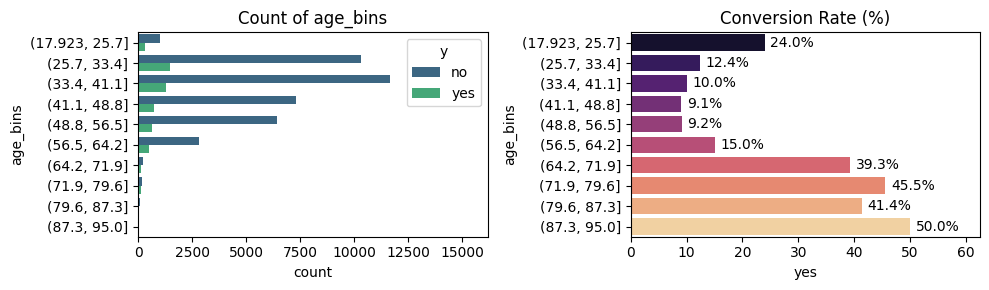

------------------ Bivariate Analysis: job vs y ------------------


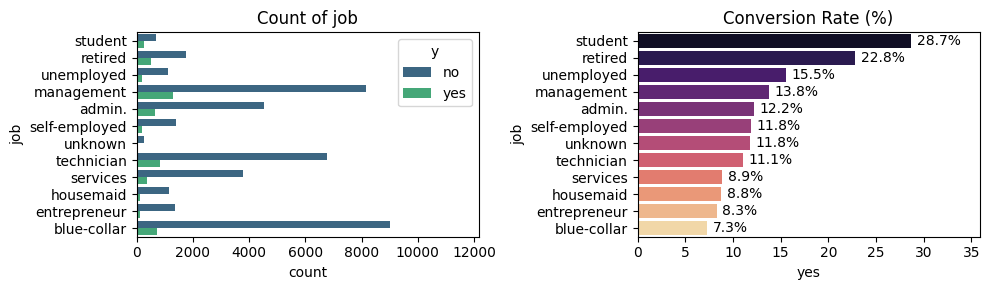

------------------ Bivariate Analysis: marital vs y ------------------


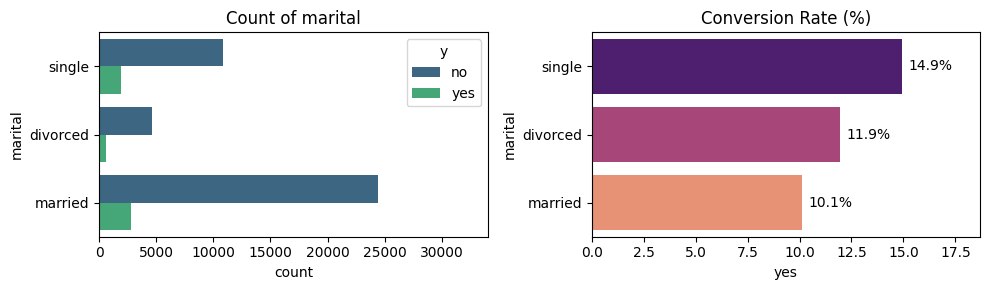

------------------ Bivariate Analysis: education vs y ------------------


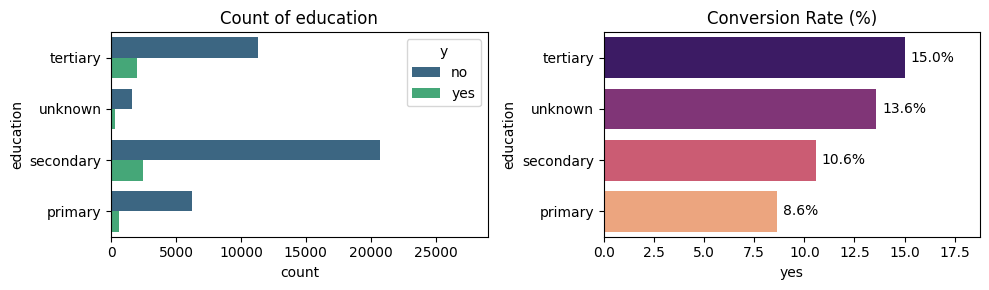

------------------ Bivariate Analysis: default vs y ------------------


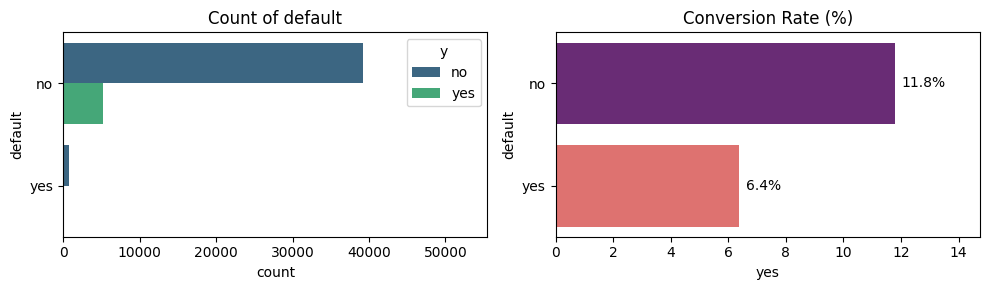

------------------ Bivariate Analysis: balance vs y ------------------


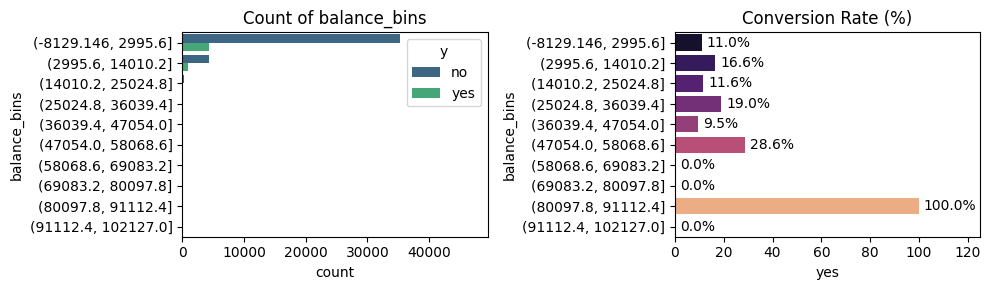

------------------ Bivariate Analysis: housing vs y ------------------


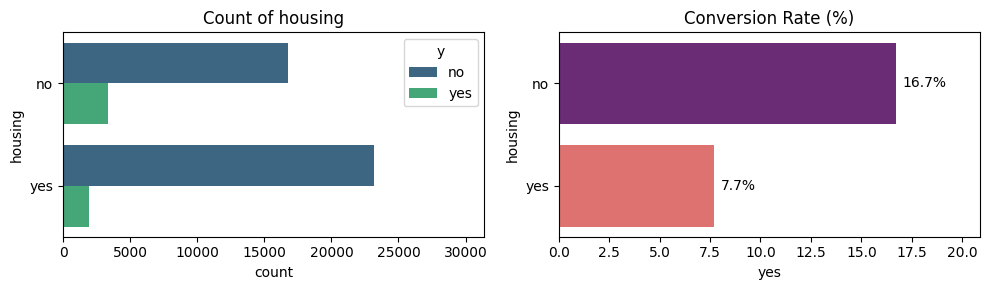

------------------ Bivariate Analysis: loan vs y ------------------


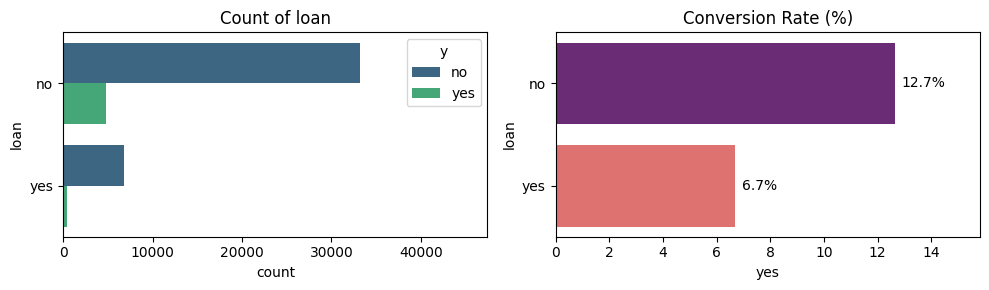

------------------ Bivariate Analysis: contact vs y ------------------


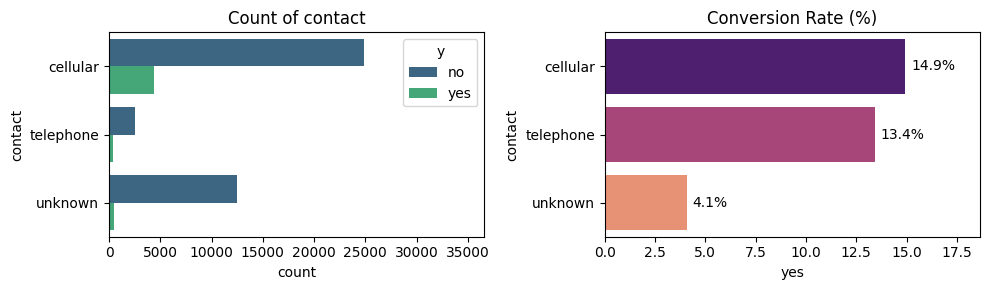

------------------ Bivariate Analysis: poutcome vs y ------------------


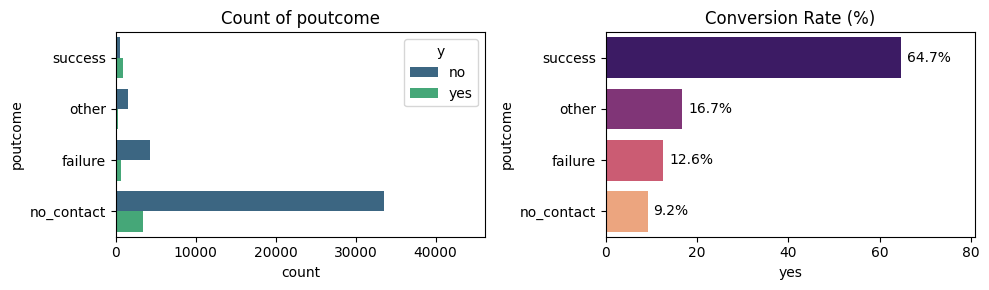

------------------ Bivariate Analysis: emp.var.rate vs y ------------------


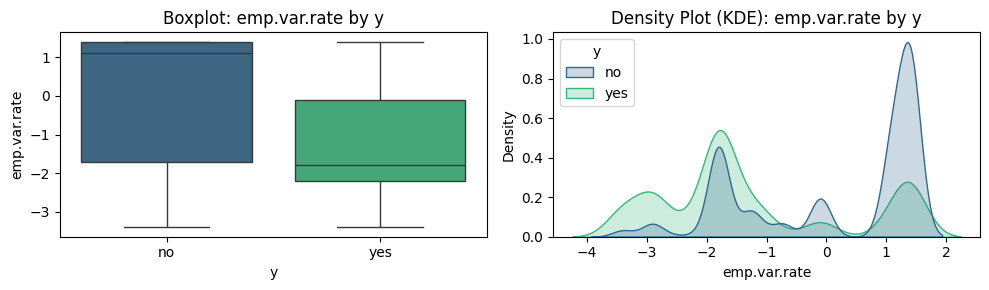

------------------ Bivariate Analysis: cons.price.idx vs y ------------------


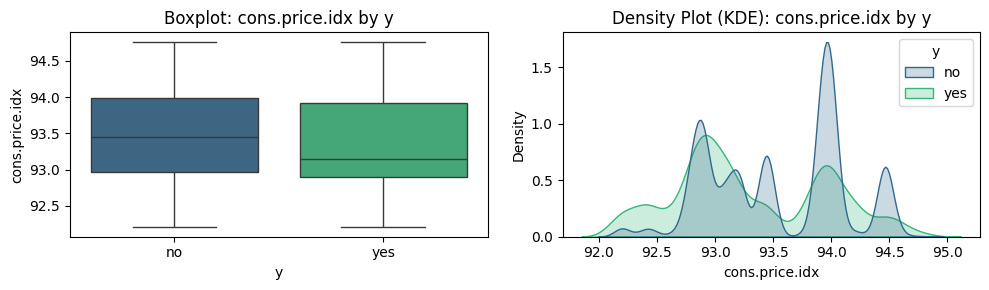

------------------ Bivariate Analysis: cons.conf.idx vs y ------------------


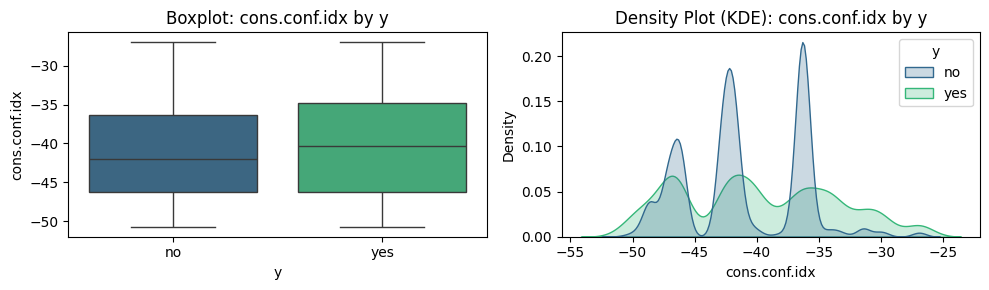

------------------ Bivariate Analysis: euribor3m vs y ------------------


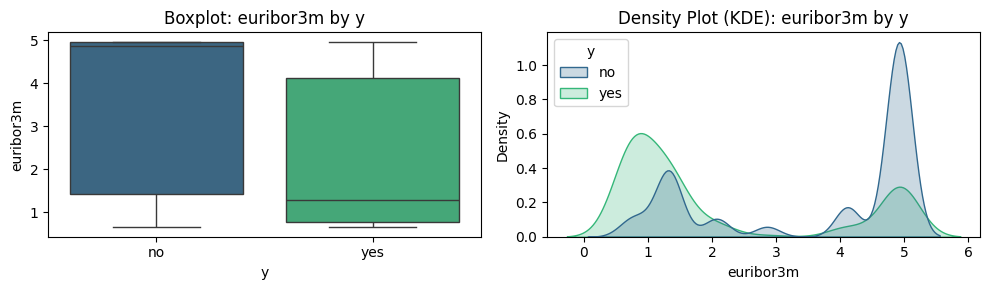

------------------ Bivariate Analysis: nr.employed vs y ------------------


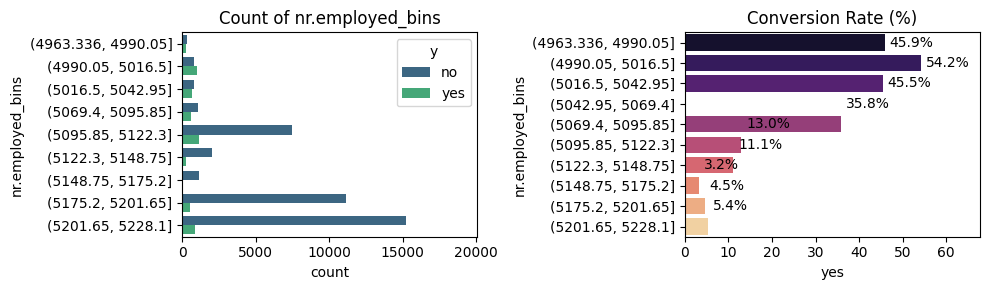

In [50]:
cols = df_merged.columns.drop(['y', 'day', 'month', 'year'], errors='ignore')
bins_cols = ['age', 'balance', 'nr.employed']

for col in cols:
    if col in bins_cols:
        analyze_bivariate(df_merged, col, bins=10)
    else:
        analyze_bivariate(df_merged, col)

In [51]:
#convert categorical to nummerical values
df_num = df_merged.copy()

df_num['y'] = df_num['y'].map({'no': 0, 'yes': 1})
df_num['education'] = df_num['education'].map({'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': -1})
for col in ['housing', 'loan', 'default']:
    df_num[col] = df_num[col].map({'yes': 1, 'no': 0, 'unknown': -1})

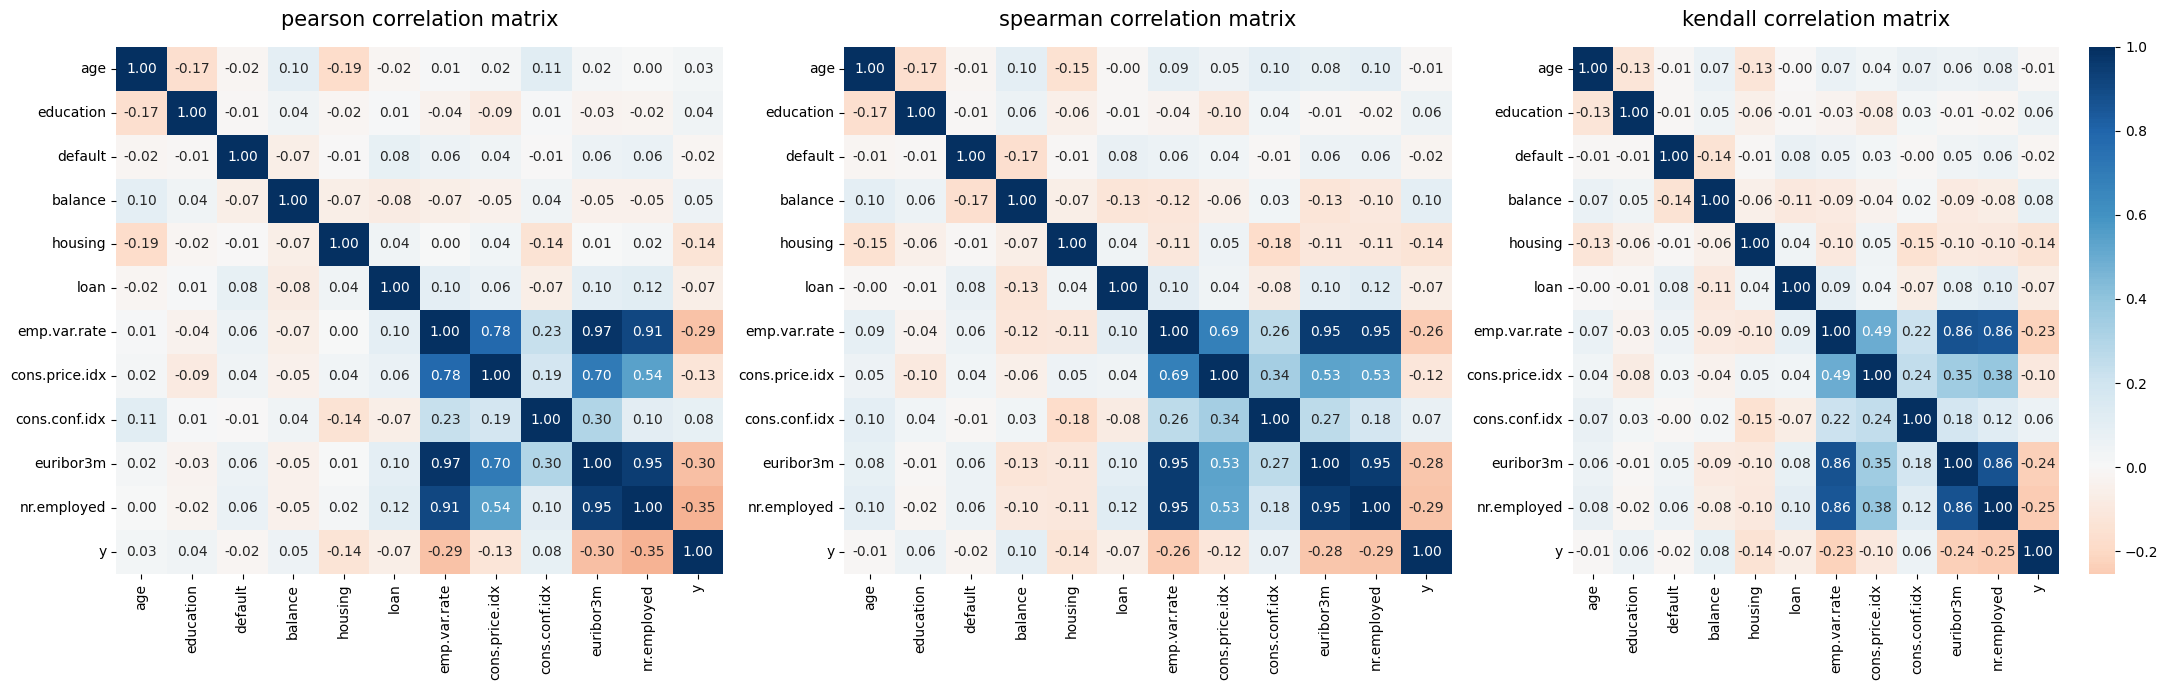

In [52]:
#correlation for all nummerical columns / converted columns

numeric_df = df_num.select_dtypes(include=['int64', 'float64']).drop(columns=['day', 'month', 'year'], errors='ignore')

methods = ['pearson', 'spearman', 'kendall']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, method in enumerate(methods):
    sns.heatmap(numeric_df.corr(method=method), annot=True, cmap='RdBu', fmt=".2f", center=0, ax=axes[i], cbar=(i == 2))
    axes[i].set_title(f"{method} correlation matrix", fontsize=15, pad=15)

plt.tight_layout()
plt.show()

correlation between economical values <br>
highest convertion rates (positive correlations) for 'balance' (2nd highest bin [but only to data points]), 'poutcome' (success) and 'nr.employed' (lower bins).  <br>
lowest convertion rates (negative correlations) for 'contact' (unknown) and 'nr.employed' (higher bins) <br>

### 01.4 Save dataframe

In [54]:
#save the processed dataframe as CSV file
df_merged.to_csv(path+'bank-extended-full.csv', sep=';', index=False, encoding='utf-8')  
